## Analysis the Spacia result for Conical Mouse Brain

### Import the packages

In [110]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os


### Read Files

In [111]:
RESULT_FOLDER = "/home/akram/share/Result/Spacia_S1R1/S1R_L5_6_Pvalb"   # <-- change if needed
OUT_DIR = "/home/akram/share/Result/spacia_aggregated_result_conical"
MODEL_INPUT = os.path.join(RESULT_FOLDER, "/home/akram/share/Result/Spacia_S1R1/S1R_L5_6_Pvalb/model_input")

### Paramters

In [112]:
FILTER_B_NEG = True
PB_CUTOFF = 1e-30
PBETA_CUTOFF = 0.001
TOP_BETA_Z_QUANTILE = 0.99

In [113]:
exp_sender_path = os.path.join(MODEL_INPUT, "exp_sender.json")
with open(exp_sender_path,'r') as fh:
    exp_sender = json.load(fh)

In [114]:
# load sender_pathways.json (to get module names / order)
sp_path = os.path.join(MODEL_INPUT, "sender_pathways.json")
sender_pathways = None
if os.path.exists(sp_path):
    with open(sp_path,'r') as fh:
        sender_pathways = json.load(fh)

In [115]:
# build module name list (ordered)
if isinstance(sender_pathways, dict):
    module_names = list(sender_pathways.keys())   # insertion order preserved in py3.7+
elif isinstance(sender_pathways, list):
    module_names = sender_pathways
else:
    # fallback: try to infer from files in model_input matching module_*_exp_receiver.csv
    files = sorted([os.path.basename(p) for p in os.listdir(MODEL_INPUT) if p.startswith("module_") and p.endswith("_exp_receiver.csv")])
    module_names = [f.split("_exp_receiver")[0] for f in files]
    if len(module_names)==0:
        module_names = None

print("Module names (sample / count):", (module_names[:10] if module_names is not None else "None found"), 
      "  count:", (len(module_names) if module_names is not None else 0))

Module names (sample / count): ['module_1', 'module_2', 'module_5', 'module_6', 'module_8', 'module_11', 'module_12', 'module_17', 'module_20']   count: 9


In [116]:
rows = []
bad = 0
for cid, val in exp_sender.items():
    # val is a list of lists (n_instances x n_modules) per screenshot
    try:
        arr = np.array(val, dtype=float)
        # if arr is 1D, make it 2D
        if arr.ndim == 1:
            arr = arr.reshape(1, -1)
        # mean across axis 0
        mean_vec = np.nanmean(arr, axis=0)
        # pick argmax
        imax = int(np.nanargmax(mean_vec))
        if module_names is not None and imax < len(module_names):
            assigned = module_names[imax]
        else:
            assigned = f"module_{imax+1}"
        rows.append((str(cid), assigned))
    except Exception as e:
        bad += 1
        # fallback: assign "module_unknown"
        rows.append((str(cid), "module_unknown"))

print(f"Built mapping for {len(rows)} cells (failed {bad}).")
cell2mod = pd.DataFrame(rows, columns=["cell_ID","sender_module"])
cell2mod.to_csv(os.path.join(OUT_DIR,"cell2module_mapping.csv"), index=False)
display(cell2mod.head(8))
print("Saved:", os.path.join(OUT_DIR,"cell2module_mapping.csv"))

Built mapping for 741 cells (failed 0).


,cell_ID,sender_module
0,239173577349788012654205822648910348288,module_2
1,102268433481709993849406855656050262016,module_2
2,256564861931513014236740064779318591488,module_2
3,299549998948568990787395259456332759040,module_2
4,163400957279013999392703977492318257152,module_11
5,43078790811549502678282035750766641152,module_20
6,167330250955770999596736984555018256384,module_11
7,188143931790406984431093402324980203520,module_11


Saved: /home/akram/share/Result/spacia_aggregated_result_conical/cell2module_mapping.csv


In [117]:
# load files
inter = pd.read_csv(os.path.join(RESULT_FOLDER,"Interactions.csv"))
pb    = pd.read_csv(os.path.join(RESULT_FOLDER,"Pathway_betas.csv"))
bdf   = pd.read_csv(os.path.join(RESULT_FOLDER,"B_and_FDR.csv"))
cell2mod = pd.read_csv(os.path.join(OUT_DIR,"cell2module_mapping.csv"))

In [118]:
# rename known columns (based on your screenshot)
inter = inter.rename(columns={"Unnamed: 0":"response_module","Receiver":"receiver_id","Sender":"sender_id","Primary_instance_score":"primary_score"})
pb    = pb.rename(columns={"Unnamed: 0":"response_module","Sender_pathway":"sender_module","Beta":"beta","pval":"pval","pval_adj":"pval_adj"})
bdf   = bdf.rename(columns={"Unnamed: 0":"module","Theta_cutoff":"theta_cutoff","FDR":"FDR","b":"b","pval":"pval","pval_adj":"pval_adj"})

# ensure string types
inter['sender_id'] = inter['sender_id'].astype(str)
inter['receiver_id'] = inter['receiver_id'].astype(str)
cell2mod['cell_ID'] = cell2mod['cell_ID'].astype(str)

In [119]:
print(inter.head(5))

  response_module                              receiver_id  \
0        module_4  239173577349788012654205822648910348288   
1        module_4  239173577349788012654205822648910348288   
2        module_4  239173577349788012654205822648910348288   
3        module_4  239173577349788012654205822648910348288   
4        module_4  239173577349788012654205822648910348288   

                                 sender_id  primary_score  
0  102030317453929998871952991423605768192       0.064267  
1   12695790993815200491288846433630814208       0.050800  
2  134231426397691997633053522135357587456       0.050133  
3  155676746097055994071580676323555672064       0.072933  
4  222772449941250007179306594585196625920       0.056400  


In [120]:
print(cell2mod.head(5))

                                   cell_ID sender_module
0  239173577349788012654205822648910348288      module_2
1  102268433481709993849406855656050262016      module_2
2  256564861931513014236740064779318591488      module_2
3  299549998948568990787395259456332759040      module_2
4  163400957279013999392703977492318257152     module_11


In [121]:
inter = inter.merge(cell2mod.rename(columns={'cell_ID':'receiver_id'}), on='receiver_id', how='left')


In [122]:
print(inter.head(5))

  response_module                              receiver_id  \
0        module_4  239173577349788012654205822648910348288   
1        module_4  239173577349788012654205822648910348288   
2        module_4  239173577349788012654205822648910348288   
3        module_4  239173577349788012654205822648910348288   
4        module_4  239173577349788012654205822648910348288   

                                 sender_id  primary_score sender_module  
0  102030317453929998871952991423605768192       0.064267      module_2  
1   12695790993815200491288846433630814208       0.050800      module_2  
2  134231426397691997633053522135357587456       0.050133      module_2  
3  155676746097055994071580676323555672064       0.072933      module_2  
4  222772449941250007179306594585196625920       0.056400      module_2  


In [123]:
# attach beta
for df in [inter, pb, bdf]:
    for col in df.columns:
        if df[col].dtype == object:
            df[col] = df[col].astype(str).str.replace(" ", "_")
# β P < 0.001
pb = pb[pb['pval'] < PBETA_CUTOFF]


# b < 0 AND b P < 1e-29 (10 × 10^-30)
bdf = bdf[(bdf['b'] < 0) & (bdf['pval'] < PB_CUTOFF)]

merged = inter.merge(
    pb[['response_module','sender_module','beta','pval','pval_adj']], 
    on=['response_module','sender_module'], how='left'
)
merged = merged.merge(
    bdf[['module','b']],
    left_on='response_module',
    right_on='module',
    how='inner'
)
merged = merged[merged['beta'].notna()]
# =========================================
# 5) TOP 1% Z-SCORED β (paper)
# =========================================

merged['beta_z'] = (merged['beta'] - merged['beta'].mean()) / merged['beta'].std()
merged = merged[ merged['beta_z'] >= merged['beta_z'].quantile(0.99) ]

merged.to_csv(os.path.join(OUT_DIR,"spacia_filtered.csv"),index=False)



In [124]:
# ============================
# 6) Gene-gene expansion
# ============================

SP_FOLDER = RESULT_FOLDER
MODEL_INPUT = os.path.join(SP_FOLDER, "model_input")
OUT_GENES = "/home/akram/share/Result/spacia_lr_ready"
os.makedirs(OUT_GENES, exist_ok=True)

# module → genes
with open(os.path.join(MODEL_INPUT, "sender_pathways.json")) as f:
    sender_path = {k.replace(" ", "_"): v for k, v in json.load(f).items()}

with open(os.path.join(MODEL_INPUT, "receiver_pathways.json")) as f:
    recv_path = {k.replace(" ", "_"): v for k, v in json.load(f).items()}

TOP_K = 5  # limit genes per module to avoid explosion

rows = []
for _, r in merged.iterrows():
    s_mod = r["sender_module"]
    r_mod = r["response_module"]

    s_genes = sender_path.get(s_mod, [])[:TOP_K]
    r_genes = recv_path.get(r_mod, [])[:TOP_K]

    for sg, rg in product(s_genes, r_genes):
        rows.append((
            s_mod,
            r_mod,
            sg,
            rg,
            r["beta"],      # module-level β
            r["pval_adj"]   # module-level β adjusted P (if you want)
        ))

out = pd.DataFrame(
    rows,
    columns=[
        "sender_module", "response_module",
        "sender_gene", "receiver_gene",
        "module_beta", "module_padj"
    ]
)
out.to_csv(os.path.join(OUT_GENES, "spacia_gene_pairs_filtered.csv"), index=False)
print("Saved", len(out), "gene-gene pairs")

Saved 42600 gene-gene pairs


In [125]:
df = pd.read_csv("/home/akram/share/Result/spacia_lr_ready/spacia_gene_pairs_filtered.csv")

In [126]:
df_unique = df.drop_duplicates(subset=["sender_gene", "receiver_gene"])


df_unique.to_csv("/home/akram/share/Result/spacia_lr_ready/spacia_gene_pairs_unique.csv", index=False)

print("Unique directed LR pairs:", len(df_unique))

Unique directed LR pairs: 25


In [ ]:
pairs = df_unique[['sender_gene', 'receiver_gene']]

for _, row in df_unique.sort_values(['sender_gene','receiver_gene']).iterrows():
    print(f"{row['sender_gene']} → {row['receiver_gene']}")

Adgra3 → Adgrd1
Adgra3 → Gpr139
Adgra3 → Man1a
Adgra3 → Ptgdr2
Adgra3 → Slc17a6
Adra1d → Adgrd1
Adra1d → Gpr139
Adra1d → Man1a
Adra1d → Ptgdr2
Adra1d → Slc17a6
Drd1 → Adgrd1
Drd1 → Gpr139
Drd1 → Man1a
Drd1 → Ptgdr2
Drd1 → Slc17a6
Gad1 → Adgrd1
Gad1 → Gpr139
Gad1 → Man1a
Gad1 → Ptgdr2
Gad1 → Slc17a6
Tmem108 → Adgrd1
Tmem108 → Gpr139
Tmem108 → Man1a
Tmem108 → Ptgdr2
Tmem108 → Slc17a6


# ##################### ----------------------------

### check the output files is exist and print the first few records

In [ ]:
# Cell C — filter, aggregate and plot
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os
OUT_DIR = "/home/akram/share/Result/spacia_aggregated_result_conical"

merged = pd.read_csv(os.path.join("/home/akram/share/Result/spacia_aggregated_result_conical/interactions_with_beta.csv"))
bdf = pd.read_csv(os.path.join("/home/akram/share/Result/End_Per_coronal_MERFISH","/home/akram/share/Result/End_Per_coronal_MERFISH/B_and_FDR.csv"))
# normalize bdf names too
bdf = bdf.rename(columns={"Unnamed: 0":"module","pval_adj":"pval_adj"})
bdf['module'] = bdf['module'].astype(str).str.replace(" ", "_")

# optional: filter modules by B_and_FDR significance (paper used strict criteria)
MODULE_PVAL_ADJ_CUTOFF = 1e-5
valid_modules = set(bdf.loc[bdf['pval_adj']<=MODULE_PVAL_ADJ_CUTOFF, 'module'].astype(str))
print("Valid modules by B_and_FDR:", valid_modules)
if len(valid_modules)>0:
    merged = merged[merged['response_module'].isin(valid_modules)]

# drop rows without beta (we need beta for strength metrics)
df = merged[~merged['beta'].isna()].copy()
print("Rows after filtering (beta not NA):", len(df))

# OPTIONAL: keep top 1% beta_z (paper used top 1% sometimes)
TOP_BETA_Z_QUANTILE = 0.99
df['beta_z'] = (df['beta'] - df['beta'].mean())/df['beta'].std()
df = df[df['beta_z'] >= df['beta_z'].quantile(TOP_BETA_Z_QUANTILE)]
# Now map sender_type and receiver_type if you have metadata.
# Try to load metadata.txt in model_input
meta_path = os.path.join("/home/akram/share/data/Image_New_paper/coronal_meta.txt")
meta = pd.read_csv(meta_path, sep=None, engine='python')


In [ ]:
import os, json, pandas as pd
from itertools import product

SP_FOLDER = "/home/akram/share/Result/End_Per_coronal_MERFISH"
MODEL_INPUT = os.path.join(SP_FOLDER, "model_input")
OUT = "/home/akram/share/Result/spacia_lr_ready"
os.makedirs(OUT, exist_ok=True)

# 1) load your filtered module pairs (use your df from Cell C)
# If df not in memory, rebuild quickly (no top-1% here — use your df build)
df = pd.read_csv(os.path.join("/home/akram/share/Result/spacia_aggregated_result_conical","interactions_with_beta.csv"))
bdf = pd.read_csv(os.path.join(SP_FOLDER,"B_and_FDR.csv"))
bdf['module'] = bdf['Unnamed: 0'].astype(str).str.replace(" ","_")
valid_modules = set(bdf.loc[bdf['pval_adj']<=1e-30,'module'].astype(str))
df['response_module'] = df['response_module'].astype(str).str.replace(" ","_")
df = df[df['response_module'].isin(valid_modules) & df['beta'].notna()]   # adjust filter if needed

# 2) load module->genes
with open(os.path.join(MODEL_INPUT,"sender_pathways.json")) as f: sender_path = {k.replace(" ","_"):v for k,v in json.load(f).items()}
with open(os.path.join(MODEL_INPUT,"receiver_pathways.json")) as f: recv_path = {k.replace(" ","_"):v for k,v in json.load(f).items()}

# 3) expand -> gene-gene but limit genes per module to TOP_K to avoid explosion
TOP_K = 5   # lower to shrink output
rows=[]
for _, r in df.iterrows():                # <- use df (filtered) not merged
    s_mod = str(r['sender_module']).replace(" ","_")
    r_mod = str(r['response_module']).replace(" ","_")
    s_genes = sender_path.get(s_mod,[])[:TOP_K]
    r_genes = recv_path.get(r_mod,[])[:TOP_K]
    for sg, rg in product(s_genes, r_genes):
        rows.append((s_mod, r_mod, sg, rg, r.get('beta'), r.get('pval_adj')))

out = pd.DataFrame(rows, columns=["sender_module","response_module","sender_gene","receiver_gene","module_beta","module_padj"])
out.to_csv(os.path.join(OUT,"spacia_gene_pairs_filtered.csv"), index=False)
print("Saved", len(out), "pairs ->", os.path.join(OUT,"spacia_gene_pairs_filtered.csv"))

In [ ]:
print(meta.head(5))

In [ ]:
# ---- find cell-type column safely ----
celltype_col = None

# 1. Preferred exact matches
preferred = {'cell_type', 'celltype', 'cell-type', 'type'}
for c in meta.columns:
    if c.lower() in preferred:
        celltype_col = c
        break

# 2. Fallback: contains 'type' but is not an ID
if celltype_col is None:
    for c in meta.columns:
        cl = c.lower()
        if 'type' in cl and cl not in {'cell_id', 'id', 'unnamed: 0'}:
            celltype_col = c
            break

# 3. Hard fail (better than silent corruption)
if celltype_col is None:
    raise ValueError(
        f"Could not infer cell-type column from metadata columns: {meta.columns.tolist()}"
    )

print("Using metadata cell-type column:", celltype_col)


In [ ]:
print(meta.head(5))

In [ ]:
if 'cell_ID' not in meta.columns:
    if 'Unnamed: 0' in meta.columns:
        meta = meta.rename(columns={'Unnamed: 0': 'cell_ID'})
    else:
        # fallback to first col containing 'id' or 'cell', or raise an error
        id_col = None
        for c in meta.columns:
            if 'id' in c.lower() or 'cell' in c.lower():
                id_col = c
                break
        if id_col is None:
            raise ValueError(f"Could not find a cell ID column in metadata: {meta.columns.tolist()}")
        meta = meta.rename(columns={id_col: 'cell_ID'})


meta['cell_ID'] = meta['cell_ID'].astype(str)
df['sender_id']   = df['sender_id'].astype(str)
df['receiver_id'] = df['receiver_id'].astype(str)

# attach types
df = df.merge(meta[['cell_ID', celltype_col]].rename(columns={'cell_ID':'sender_id', celltype_col:'sender_type'}),
              on='sender_id', how='left')
df = df.merge(meta[['cell_ID', celltype_col]].rename(columns={'cell_ID':'receiver_id', celltype_col:'receiver_type'}),
              on='receiver_id', how='left')

print("After attaching types, unique sender types:", df['sender_type'].nunique(), 
      "unique receiver types:", df['receiver_type'].nunique())

In [ ]:
# Aggregate metrics
count_mat = df.groupby(['sender_type','receiver_type']).size().unstack(fill_value=0)
sum_beta_mat = df.groupby(['sender_type','receiver_type'])['beta'].sum().unstack(fill_value=0)
mean_beta_mat = df.groupby(['sender_type','receiver_type'])['beta'].mean().unstack()

# Save matrices
count_mat.to_csv(os.path.join(OUT_DIR,"matrix_count.csv"))
sum_beta_mat.to_csv(os.path.join(OUT_DIR,"matrix_sum_beta.csv"))
mean_beta_mat.to_csv(os.path.join(OUT_DIR,"matrix_mean_beta.csv"))
print("Saved matrices to", OUT_DIR)

# Plot heatmap (counts)
plt.figure(figsize=(8, max(4,0.35*count_mat.shape[0])))
sns.heatmap(count_mat, annot=True, fmt=".0f", cmap="viridis", linewidths=.5)
plt.title("Count of significant interactions (sender -> receiver)")
plt.ylabel("Sender type")
plt.xlabel("Receiver type")
plt.tight_layout()
plt.show()


# Test the combaination of the files in one result

In [1]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
RESULT_FOLDERS = {
    "End_Per": "/home/akram/share/Result/End_Per_coronal_MERFISH",
    "Neu_Tcell": "/home/akram/share/Result/Neu_Tcell_coronal_MERFISH",
    "Per_End": "/home/akram/share/Result/Per_End_coronal_MERFISH",
}
OUT_DIR = "/home/akram/share/Result/spacia_aggregated_result_conical"
FILTER_B_NEG = True
PB_CUTOFF = 1e-30
PBETA_CUTOFF = 0.001
TOP_BETA_Z_QUANTILE = 0.99
#MODULE_PVAL_ADJ_CUTOFF = 1e-5

In [3]:
meta_path = "/home/akram/share/data/Image_New_paper/coronal_meta.txt"
meta = pd.read_csv(meta_path, sep=None, engine="python")

In [4]:
# ---- find cell-type column safely ----
celltype_col = None

# 1. Preferred exact matches
preferred = {'cell_type', 'celltype', 'cell-type', 'type'}
for c in meta.columns:
    if c.lower() in preferred:
        celltype_col = c
        break

# 2. Fallback: contains 'type' but is not an ID
if celltype_col is None:
    for c in meta.columns:
        cl = c.lower()
        if 'type' in cl and cl not in {'cell_id', 'id', 'unnamed: 0'}:
            celltype_col = c
            break

# 3. Hard fail
if celltype_col is None:
    raise ValueError(
        f"Could not infer cell-type column from metadata columns: {meta.columns.tolist()}"
    )

print("Using metadata cell-type column:", celltype_col)

Using metadata cell-type column: cell_type


In [5]:
# ensure cell_ID column
if 'cell_ID' not in meta.columns:
    if 'Unnamed: 0' in meta.columns:
        meta = meta.rename(columns={'Unnamed: 0': 'cell_ID'})
    else:
        id_col = None
        for c in meta.columns:
            if 'id' in c.lower() or 'cell' in c.lower():
                id_col = c
                break
        if id_col is None:
            raise ValueError(f"Could not find a cell ID column in metadata: {meta.columns.tolist()}")
        meta = meta.rename(columns={id_col: 'cell_ID'})

meta['cell_ID'] = meta['cell_ID'].astype(str)

In [ ]:
def process_folder(label, RESULT_FOLDER):
    print(f"\n=== Processing dataset: {label} ===")
    
    MODEL_INPUT = os.path.join(RESULT_FOLDER, "model_input")
    
    # --- load exp_sender.json ---
    exp_sender_path = os.path.join(MODEL_INPUT, "exp_sender.json")
    with open(exp_sender_path, 'r') as fh:
        exp_sender = json.load(fh)
    
    # --- load sender_pathways.json (if exists) ---
    sp_path = os.path.join(MODEL_INPUT, "sender_pathways.json")
    sender_pathways = None
    if os.path.exists(sp_path):
        with open(sp_path, 'r') as fh:
            sender_pathways = json.load(fh)
    
    # --- build module name list (ordered) ---
    if isinstance(sender_pathways, dict):
        module_names = list(sender_pathways.keys())   # insertion order
    elif isinstance(sender_pathways, list):
        module_names = sender_pathways
    else:
        # fallback: infer from files in model_input
        files = sorted([
            os.path.basename(p)
            for p in os.listdir(MODEL_INPUT)
            if p.startswith("module_") and p.endswith("_exp_receiver.csv")
        ])
        module_names = [f.split("_exp_receiver")[0] for f in files]
        if len(module_names) == 0:
            module_names = None

    print("Module names (sample / count):",
          (module_names[:10] if module_names is not None else "None found"),
          "  count:", (len(module_names) if module_names is not None else 0))
    
    # --- build cell -> sender_module mapping (your previous loop) ---
    rows = []
    bad = 0
    for cid, val in exp_sender.items():
        try:
            arr = np.array(val, dtype=float)
            if arr.ndim == 1:
                arr = arr.reshape(1, -1)
            mean_vec = np.nanmean(arr, axis=0)
            imax = int(np.nanargmax(mean_vec))
            if module_names is not None and imax < len(module_names):
                assigned = module_names[imax]
            else:
                assigned = f"module_{imax+1}"
            rows.append((str(cid), assigned))
        except Exception:
            bad += 1
            rows.append((str(cid), "module_unknown"))

    print(f"Built mapping for {len(rows)} cells (failed {bad}).")
    cell2mod = pd.DataFrame(rows, columns=["cell_ID", "sender_module"])
    
    # save (with dataset label in filename so they don't overwrite)
    mapping_path = os.path.join(OUT_DIR, f"cell2module_mapping_{label}.csv")
    cell2mod.to_csv(mapping_path, index=False)
    print("Saved:", mapping_path)
    
    # --- load interaction-related files from this RESULT_FOLDER ---
    inter = pd.read_csv(os.path.join(RESULT_FOLDER, "Interactions.csv"))
    pb    = pd.read_csv(os.path.join(RESULT_FOLDER, "Pathway_betas.csv"))
    bdf   = pd.read_csv(os.path.join(RESULT_FOLDER, "B_and_FDR.csv"))
    
    # --- rename known columns (same as your code) ---
    inter = inter.rename(columns={
        "Unnamed: 0": "response_module",
        "Receiver": "receiver_id",
        "Sender": "sender_id",
        "Primary_instance_score": "primary_score"
    })
    pb = pb.rename(columns={
        "Unnamed: 0": "response_module",
        "Sender_pathway": "sender_module",
        "Beta": "beta",
        "pval": "pval",
        "pval_adj": "pval_adj"
    })
    bdf = bdf.rename(columns={
        "Unnamed: 0": "module",
        "Theta_cutoff": "theta_cutoff",
        "FDR": "FDR",
        "b": "b",
        "pval": "pval",
        "pval_adj": "pval_adj"
    })
    
    # ensure string types
    inter['sender_id'] = inter['sender_id'].astype(str)
    inter['receiver_id'] = inter['receiver_id'].astype(str)
    cell2mod['cell_ID'] = cell2mod['cell_ID'].astype(str)
    
    # --- attach sender_module to receiver_id (as in your original code) ---
    inter = inter.merge(
        cell2mod.rename(columns={'cell_ID': 'receiver_id'}),
        on='receiver_id',
        how='left'
    )
    
    # --- normalize strings to avoid "module 1" vs "module_1" ---
    for df_ in [inter, pb, bdf]:
        for col in df_.columns:
            if df_[col].dtype == object:
                df_[col] = df_[col].astype(str).str.replace(" ", "_")
    
    # --- merge beta by (response_module, sender_module) ---
    merged = inter.merge(
        pb[['response_module', 'sender_module', 'beta', 'pval', 'pval_adj']],
        on=['response_module', 'sender_module'],
        how='left'
    )
    
    print("After merge: total rows:", len(merged),
          " — rows with beta:", merged['beta'].notna().sum())
    
    merged_path = os.path.join(OUT_DIR, f"interactions_with_beta_{label}.csv")
    merged.to_csv(merged_path, index=False)
    print("Saved interactions_with_beta to", merged_path)
    
    # ----------------------------------------------------------------
    # Now apply the same filtering & metadata attachment as in Cell C
    # ----------------------------------------------------------------
    # use this dataset's B_and_FDR for module filtering
    bdf_local = bdf.copy()
    bdf_local['module'] = bdf_local['module'].astype(str).str.replace(" ", "_")
    
    valid_modules = set(
        bdf_local.loc[bdf_local['pval_adj'] <= MODULE_PVAL_ADJ_CUTOFF, 'module'].astype(str)
    )
    print("Valid modules by B_and_FDR in", label, ":", len(valid_modules))
    if len(valid_modules) > 0:
        merged = merged[merged['response_module'].isin(valid_modules)]
    
    # drop rows without beta
    df = merged[~merged['beta'].isna()].copy()
    print(f"[{label}] Rows after filtering (beta not NA):", len(df))
    
    # top 1% beta_z
    if df['beta'].std() == 0 or np.isnan(df['beta'].std()):
        # avoid division by zero if all beta are identical
        df['beta_z'] = 0.0
    else:
        df['beta_z'] = (df['beta'] - df['beta'].mean()) / df['beta'].std()
    df = df[df['beta_z'] >= df['beta_z'].quantile(TOP_BETA_Z_QUANTILE)]
    print(f"[{label}] Rows after beta_z quantile filter:", len(df))
    
    # attach metadata-based sender_type / receiver_type
    df['sender_id'] = df['sender_id'].astype(str)
    df['receiver_id'] = df['receiver_id'].astype(str)
    
    df = df.merge(
        meta[['cell_ID', celltype_col]].rename(
            columns={'cell_ID': 'sender_id', celltype_col: 'sender_type'}
        ),
        on='sender_id',
        how='left'
    )
    df = df.merge(
        meta[['cell_ID', celltype_col]].rename(
            columns={'cell_ID': 'receiver_id', celltype_col: 'receiver_type'}
        ),
        on='receiver_id',
        how='left'
    )
    
    print(f"[{label}] unique sender types:", df['sender_type'].nunique(),
          "unique receiver types:", df['receiver_type'].nunique())
    
    # keep track of which dataset this came from
    df['dataset'] = label
    
    return df

In [7]:
all_dfs = []
for label, folder in RESULT_FOLDERS.items():
    df_label = process_folder(label, folder)
    all_dfs.append(df_label)


=== Processing dataset: End_Per ===
Module names (sample / count): ['module_1', 'module_2', 'module_8', 'module_9', 'module_10', 'module_11', 'module_17', 'module_19', 'module_26']   count: 9
Built mapping for 5000 cells (failed 0).
Saved: /home/akram/share/Result/spacia_aggregated_result_conical/cell2module_mapping_End_Per.csv
After merge: total rows: 331880  — rows with beta: 331880
Saved interactions_with_beta to /home/akram/share/Result/spacia_aggregated_result_conical/interactions_with_beta_End_Per.csv


NameError: name 'MODULE_PVAL_ADJ_CUTOFF' is not defined

In [ ]:

# concatenate all datasets
df_all = pd.concat(all_dfs, ignore_index=True)
print("\nCombined df_all shape:", df_all.shape)

In [ ]:
count_mat = df_all.groupby(['sender_type', 'receiver_type']).size().unstack(fill_value=0)
sum_beta_mat = df_all.groupby(['sender_type', 'receiver_type'])['beta'].sum().unstack(fill_value=0)
mean_beta_mat = df_all.groupby(['sender_type', 'receiver_type'])['beta'].mean().unstack()

# Save matrices
count_mat.to_csv(os.path.join(OUT_DIR, "matrix_count_combined.csv"))
sum_beta_mat.to_csv(os.path.join(OUT_DIR, "matrix_sum_beta_combined.csv"))
mean_beta_mat.to_csv(os.path.join(OUT_DIR, "matrix_mean_beta_combined.csv"))
print("Saved combined matrices to", OUT_DIR)

# Plot combined heatmap (counts)
plt.figure(figsize=(8, max(4, 0.35 * count_mat.shape[0])))
sns.heatmap(count_mat, annot=True, fmt=".0f", cmap="viridis", linewidths=.5)
plt.title("Count of significant interactions combined: all datasets cell type Spacia")
plt.ylabel("Sender type")
plt.xlabel("Receiver type")
plt.tight_layout()
plt.show()


# SEcond test after fit the filters

In [1]:
import os, json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itertools import product

In [12]:
RESULT_FOLDERS = {
    "Astro_Oligo": "/home/akram/share/Result/Spacia_S1R1/S1R_Astro_Oligo",
    "Astro_Pvalb": "/home/akram/share/Result/Spacia_S1R1/S1R_Astro_Pvalb",
    "Endo_PVM": "/home/akram/share/Result/Spacia_S1R1/S1R_Endo_PVM",
    "Endo_SMC": "/home/akram/share/Result/Spacia_S1R1/S1R_Endo_SMC",
    "Endo_VLMC": "/home/akram/share/Result/Spacia_S1R1/S1R_Endo_VLMC",
    "L5_PT_CTX_Pvalb": "/home/akram/share/Result/Spacia_S1R1/S1R_L5_6_Pvalb",
    "L6_CT_CTX_Micro_PVM": "/home/akram/share/Result/Spacia_S1R1/S1R_L6_PVM",
    "L45_L45": "/home/akram/share/Result/Spacia_S1R1/S1R_L45_L45", #--------------
    "L45_Pvalb": "/home/akram/share/Result/Spacia_S1R1/S1R_L45_PVM",
    "Meis2_SMC_Peri": "/home/akram/share/Result/Spacia_S1R1/S1R_Meis2_SMC",
    "Oligo_Endo": "/home/akram/share/Result/Spacia_S1R1/S1R_Oligo_Endo",
    "Oligo_PVM": "/home/akram/share/Result/Spacia_S1R1/S1R_Oligo_PVM",
    "Oligo_VLMC": "/home/akram/share/Result/Spacia_S1R1/S1R_Oligo_VLMC",
    "Pvalb_PVM": "/home/akram/share/Result/Spacia_S1R1/S1R_Pvalb_PVM",
    "Pvalb_SMC_Peri": "/home/akram/share/Result/Spacia_S1R1/S1R_Pvalb_SMC",
    "PVM_Pvalb": "/home/akram/share/Result/Spacia_S1R1/S1R_PVM_Pvalb",
    "SMC_Pvalb": "/home/akram/share/Result/Spacia_S1R1/S1R_SMC_PVM",
    "Vip_PVM": "/home/akram/share/Result/Spacia_S1R1/S1R_Vip_PVM",
    "VLMC_SMC": "/home/akram/share/Result/Spacia_S1R1/S1R_VLMC_SMC",
    "CTX_PVM": "/home/akram/share/Result/Spacia_S1R1/S1R1_CTX_PVM",
    "VLMC_Endo": "/home/akram/share/Result/Spacia_S1R1/S1R1_VLMC_Endo"
}

OUT_DIR = "/home/akram/share/Result/spacia_aggregated_result_conical/spacia_aggregated_result_S1R1_withtop5"


In [13]:
PB_CUTOFF = 1e-30 #30
PBETA_CUTOFF = 0.001 #0.001
TOP_BETA_Z_QUANTILE = 0.99
TOP_K_GENES = 5


In [14]:
meta_path = "/home/akram/share/Result/Spacia_S1R1/S1R1_meta.txt"
meta = pd.read_csv(meta_path, sep=None, engine="python")

# infer cell-type column
celltype_col = None
preferred = {'cell_type', 'celltype', 'cell-type', 'type'}
for c in meta.columns:
    if c.lower() in preferred:
        celltype_col = c
        break
if celltype_col is None:
    for c in meta.columns:
        if 'type' in c.lower() and c.lower() not in {'cell_id', 'id', 'unnamed: 0'}:
            celltype_col = c
            break
if celltype_col is None:
    raise ValueError(f"Could not infer cell-type column from {meta.columns.tolist()}")

print("Using metadata cell-type column:", celltype_col)

Using metadata cell-type column: cell_type


In [15]:
# ensure cell_ID
if 'cell_ID' not in meta.columns:
    if 'Unnamed: 0' in meta.columns:
        meta = meta.rename(columns={'Unnamed: 0': 'cell_ID'})
    else:
        for c in meta.columns:
            if 'id' in c.lower() or 'cell' in c.lower():
                meta = meta.rename(columns={c: 'cell_ID'})
                break

meta['cell_ID'] = meta['cell_ID'].astype(str)

In [16]:
def process_folder(label, RESULT_FOLDER):

    print(f"\n=== Processing {label} ===")
    MODEL_INPUT = os.path.join(RESULT_FOLDER, "model_input")

    # ---- exp_sender ----
    with open(os.path.join(MODEL_INPUT, "exp_sender.json")) as f:
        exp_sender = json.load(f)

    # ---- sender pathways ----
    with open(os.path.join(MODEL_INPUT, "sender_pathways.json")) as f:
        sender_pathways = json.load(f)

    module_names = list(sender_pathways.keys())

    # ---- cell → sender_module ----
    rows = []
    for cid, val in exp_sender.items():
        try:
            arr = np.array(val, dtype=float)
            if arr.ndim == 1:
                arr = arr.reshape(1, -1)
            imax = int(np.nanargmax(np.nanmean(arr, axis=0)))
            mod = module_names[imax] if imax < len(module_names) else f"module_{imax+1}"
        except Exception:
            mod = "module_unknown"
        rows.append((str(cid), mod))

    cell2mod = pd.DataFrame(rows, columns=["cell_ID", "sender_module"])

    # ---- load SPACIA outputs ----
    inter = pd.read_csv(os.path.join(RESULT_FOLDER, "Interactions.csv"))
    pb    = pd.read_csv(os.path.join(RESULT_FOLDER, "Pathway_betas.csv"))
    bdf   = pd.read_csv(os.path.join(RESULT_FOLDER, "B_and_FDR.csv"))

    # ---- rename ----
    inter = inter.rename(columns={
        "Unnamed: 0": "response_module",
        "Receiver": "receiver_id",
        "Sender": "sender_id"
    })
    pb = pb.rename(columns={
        "Unnamed: 0": "response_module",
        "Sender_pathway": "sender_module",
        "Beta": "beta",
        "pval": "pval",
        "pval_adj": "pval_adj"
    })
    bdf = bdf.rename(columns={
        "Unnamed: 0": "module",
        "b": "b",
        "pval": "pval"
    })

    # ---- normalize strings ----
    for df_ in [inter, pb, bdf, cell2mod]:
        for c in df_.columns:
            if df_[c].dtype == object:
                df_[c] = df_[c].astype(str).str.replace(" ", "_")

    inter['sender_id'] = inter['sender_id'].astype(str)
    inter['receiver_id'] = inter['receiver_id'].astype(str)

    # ---- attach receiver module ----
    inter = inter.merge(
        cell2mod.rename(columns={'cell_ID': 'receiver_id'}),
        on='receiver_id',
        how='left'
    )

    # ============================
    # SAME FILTERS AS FIRST CODE
    # ============================
    pb = pb[pb['pval'] < PBETA_CUTOFF]
    bdf = bdf[(bdf['b'] < 0) & (bdf['pval'] < PB_CUTOFF)]

    merged = inter.merge(
        pb[['response_module', 'sender_module', 'beta', 'pval_adj']],
        on=['response_module', 'sender_module'],
        how='left'
    )

    merged = merged.merge(
        bdf[['module', 'b']],
        left_on='response_module',
        right_on='module',
        how='inner'
    )

    merged = merged[merged['beta'].notna()]

    # ---- top 1% beta ----
    merged['beta_z'] = (merged['beta'] - merged['beta'].mean()) / merged['beta'].std()
    merged = merged[merged['beta_z'] >= merged['beta_z'].quantile(TOP_BETA_Z_QUANTILE)]

    # ---- attach cell types ----
    merged = merged.merge(
        meta[['cell_ID', celltype_col]].rename(
            columns={'cell_ID': 'sender_id', celltype_col: 'sender_type'}
        ),
        on='sender_id',
        how='left'
    )
    merged = merged.merge(
        meta[['cell_ID', celltype_col]].rename(
            columns={'cell_ID': 'receiver_id', celltype_col: 'receiver_type'}
        ),
        on='receiver_id',
        how='left'
    )

    merged['dataset'] = label

    # ============================
    # GENE–GENE EXPANSION
    # ============================
    with open(os.path.join(MODEL_INPUT, "receiver_pathways.json")) as f:
        recv_pathways = json.load(f)

    gene_rows = []
    #[:TOP_K_GENES]
    for _, r in merged.iterrows():
        s_genes = sender_pathways.get(r['sender_module'], [])[:TOP_K_GENES]
        r_genes = recv_pathways.get(r['response_module'], [])[:TOP_K_GENES]

        for sg, rg in product(s_genes, r_genes):
            gene_rows.append((
                label,
                r['sender_type'], r['receiver_type'],
                r['sender_module'], r['response_module'],
                sg, rg,
                r['beta'], r['pval_adj']
            ))

    gene_df = pd.DataFrame(
        gene_rows,
        columns=[
            "dataset",
            "sender_type", "receiver_type",
            "sender_module", "response_module",
            "sender_gene", "receiver_gene",
            "module_beta", "module_padj"
        ]
    )

    gene_df.to_csv(
        os.path.join(OUT_DIR, f"spacia_gene_pairs_filtered_{label}.csv"),
        index=False
    )

    print(f"[{label}] cells:", len(merged), " gene pairs:", len(gene_df))

    return merged, gene_df

In [17]:
# ============================
# RUN ALL DATASETS
# ============================
cell_dfs = []
gene_dfs = []

for label, folder in RESULT_FOLDERS.items():
    df_cell, df_gene = process_folder(label, folder)
    cell_dfs.append(df_cell)
    gene_dfs.append(df_gene)

df_all = pd.concat(cell_dfs, ignore_index=True)
df_genes_all = pd.concat(gene_dfs, ignore_index=True)

df_genes_all.to_csv(
    os.path.join(OUT_DIR, "spacia_gene_pairs_filtered_ALL.csv"),
    index=False
)
print("Combined cells:", df_all.shape)
print("Combined gene pairs:", df_genes_all.shape)


=== Processing Astro_Oligo ===
[Astro_Oligo] cells: 18991  gene pairs: 474775

=== Processing Astro_Pvalb ===
[Astro_Pvalb] cells: 22781  gene pairs: 569525

=== Processing Endo_PVM ===
[Endo_PVM] cells: 14793  gene pairs: 369825

=== Processing Endo_SMC ===
[Endo_SMC] cells: 5909  gene pairs: 147725

=== Processing Endo_VLMC ===
[Endo_VLMC] cells: 13874  gene pairs: 346850

=== Processing L5_PT_CTX_Pvalb ===
[L5_PT_CTX_Pvalb] cells: 1704  gene pairs: 42600

=== Processing L6_CT_CTX_Micro_PVM ===
[L6_CT_CTX_Micro_PVM] cells: 4623  gene pairs: 115575

=== Processing L45_L45 ===
[L45_L45] cells: 17388  gene pairs: 434700

=== Processing L45_Pvalb ===
[L45_Pvalb] cells: 0  gene pairs: 0

=== Processing Meis2_SMC_Peri ===
[Meis2_SMC_Peri] cells: 235  gene pairs: 5875

=== Processing Oligo_Endo ===
[Oligo_Endo] cells: 8762  gene pairs: 219050

=== Processing Oligo_PVM ===
[Oligo_PVM] cells: 10016  gene pairs: 250400

=== Processing Oligo_VLMC ===
[Oligo_VLMC] cells: 22427  gene pairs: 5606

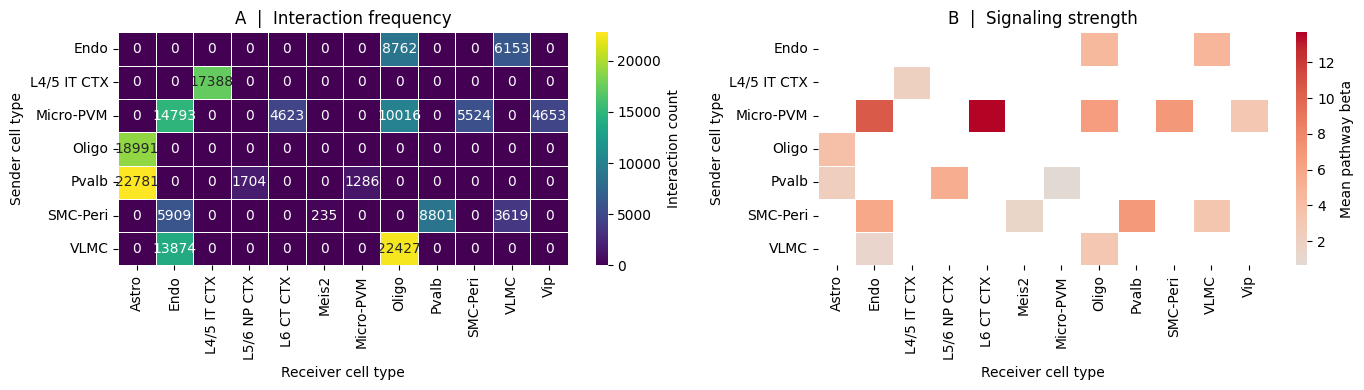

In [21]:
# Count of interactions
count_mat = (
    df_all
    .groupby(['sender_type', 'receiver_type'])
    .size()
    .unstack(fill_value=0)
)

# Mean beta (signaling strength)
mean_beta_mat = (
    df_all
    .groupby(['sender_type', 'receiver_type'])['beta']
    .mean()
    .unstack()
)

# Optional: mask low-count pairs in mean beta
min_n = 3
mean_beta_masked = mean_beta_mat.mask(count_mat < min_n)
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, max(4, 0.35 * count_mat.shape[0]))
)

# ============================
# Panel A — Count heatmap
# ============================
sns.heatmap(
    count_mat,
    ax=axes[0],
    cmap="viridis",
    annot=True,
    fmt=".0f",
    linewidths=0.5,
    cbar_kws={"label": "Interaction count"}
)

axes[0].set_title("A  |  Interaction frequency")
axes[0].set_xlabel("Receiver cell type")
axes[0].set_ylabel("Sender cell type")

# ============================
# Panel B — Mean beta heatmap
# ============================
sns.heatmap(
    mean_beta_masked,
    ax=axes[1],
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Mean pathway beta"}
)

axes[1].set_title("B  |  Signaling strength")
axes[1].set_xlabel("Receiver cell type")
axes[1].set_ylabel("Sender cell type")  # shared y-axis

plt.tight_layout()
plt.show()



In [22]:
df = df = pd.read_csv(f"{OUT_DIR}/spacia_gene_pairs_filtered_ALL.csv")
df_unique = df.drop_duplicates(subset=["sender_gene", "receiver_gene"])


df_unique.to_csv(f"{OUT_DIR}/spacia_gene_pairs_unique_ALL.csv", index=False)

print("Unique directed LR pairs:", len(df_unique))
pairs = df_unique[['sender_gene', 'receiver_gene']]

for _, row in df_unique.sort_values(['sender_gene','receiver_gene']).iterrows():
    print(f"{row['sender_gene']} → {row['receiver_gene']}")

Unique directed LR pairs: 454
Ackr1 → Ackr1
Ackr1 → Adgrg6
Ackr1 → Adra1a
Ackr1 → Adra1d
Ackr1 → Arhgap29
Ackr1 → Cnr1
Ackr1 → Ddr2
Ackr1 → Drd5
Ackr1 → Gpr161
Ackr1 → Gpr182
Ackr1 → Gpr22
Ackr1 → Grm5
Ackr1 → Hrh3
Ackr1 → Lpar1
Ackr1 → Mrgprf
Ackr1 → Pdgfrb
Ackr3 → Adgrg1
Ackr3 → Fzd1
Ackr3 → Gpr37l1
Ackr3 → Ntsr2
Ackr3 → S1pr1
Adgra1 → Ackr1
Adgra1 → Celsr3
Adgra1 → Grm1
Adgra1 → Grm4
Adgra1 → Grm5
Adgra3 → Adgrd1
Adgra3 → Gpr139
Adgra3 → Man1a
Adgra3 → Ptgdr2
Adgra3 → Slc17a6
Adgrb1 → Chrm1
Adgrb1 → Gpr88
Adgrb1 → Grm2
Adgrb1 → Slc17a7
Adgrb1 → Vipr1
Adgrb3 → Ackr1
Adgrb3 → Casr
Adgrb3 → Celsr3
Adgrb3 → Chrm1
Adgrb3 → Chrm3
Adgrb3 → Gpr88
Adgrb3 → Grm1
Adgrb3 → Grm2
Adgrb3 → Grm4
Adgrb3 → Grm5
Adgrb3 → Htr1b
Adgrb3 → Npffr2
Adgrb3 → Npsr1
Adgrb3 → Slc17a7
Adgrb3 → Vipr1
Adgrf5 → Ackr1
Adgrf5 → Adgrg6
Adgrf5 → Ddr2
Adgrf5 → Gpr182
Adgrf5 → Lpar1
Adgrg6 → Arhgap29
Adgrg6 → Gpr182
Adgrg6 → Lpar1
Adgrg6 → Mrgprf
Adgrg6 → Pdgfrb
Adgrl1 → Chrm1
Adgrl1 → Gpr88
Adgrl1 → Grm2
Adgrl1 → Slc17a

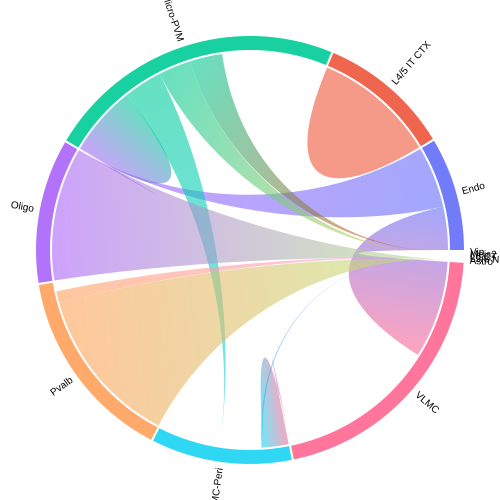

In [20]:
import os
import pandas as pd
import openchord as ocd

# 1️⃣ Generate matrices
count_mat = df_all.groupby(['sender_type', 'receiver_type']).size().unstack(fill_value=0)
sum_beta_mat = df_all.groupby(['sender_type', 'receiver_type'])['beta'].sum().unstack(fill_value=0)
mean_beta_mat = df_all.groupby(['sender_type', 'receiver_type'])['beta'].mean().unstack()

# 2️⃣ Save matrices
count_mat.to_csv(os.path.join(OUT_DIR, "matrix_count_combined.csv"))
sum_beta_mat.to_csv(os.path.join(OUT_DIR, "matrix_sum_beta_combined.csv"))
mean_beta_mat.to_csv(os.path.join(OUT_DIR, "matrix_mean_beta_combined.csv"))

# 3️⃣ Prepare labels in consistent order
senders = list(count_mat.index)
receivers = list(count_mat.columns)

# Combine sender and receiver labels for chord diagram labels
labels = senders + [r for r in receivers if r not in senders]

# 4️⃣ Build adjacency matrix for chord diagram
import numpy as np

# Initialize square matrix with zeros
size = len(labels)
adjacency_matrix = np.zeros((size, size))

# Fill in sender->receiver values in appropriate matrix positions
for i, sender in enumerate(senders):
    for j, receiver in enumerate(receivers):
        sender_idx = labels.index(sender)
        receiver_idx = labels.index(receiver)
        adjacency_matrix[sender_idx, receiver_idx] = count_mat.loc[sender, receiver]

# 5️⃣ Create chord diagram
fig = ocd.Chord(adjacency_matrix.tolist(), labels)

# 6️⃣ Optional: Set colors (make sure you have enough for all labels)
fig.colormap = [
    '#636EFA', '#EF553B', '#00CC96', '#AB63FA',
    '#FFA15A', '#19D3F3', '#FF6692', '#B6E880',
    '#FF97FF', '#FECB52', '#8A2BE2', '#FF4500', '#2E8B57'
][:len(labels)]  # truncate or extend as needed

# 7️⃣ Show the plot
fig.show()


### cell-type interaction strength based on significant Spacia interactions

In [11]:
# Save Spacia final cell-type interaction matrix
spacia_mat = mean_beta_masked.copy()
spacia_mat.to_csv("/home/akram/share/Result/Spacia_S1R1/Spacia_celltype_matrix_S1R1.csv")
print("Saved: Spacia_celltype_matrix_S1R1.csv")

Saved: Spacia_celltype_matrix_S1R1.csv
